In [ ]:
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Conv2D,MaxPooling2D,UpSampling2D,Dense
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [ ]:
(x_train,_),(x_test,_) = mnist.load_data()  #we dont need y(output)..we just need image,bcoz we are taking image as input and again generating back image itself
                                            #But we need to give in this format.so instead of y we gave (_)here.we dont bother about y_train,y_test

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
x_train.shape,x_test.shape

((60000, 28, 28), (10000, 28, 28))

In [ ]:
x_train.dtype  #uint- unsigned(no negative value) integer

dtype('uint8')

In [ ]:
#Normalization(output value will be btw 0 to 1)  #also we changed the datatype into float

x_train = x_train.astype('float32')/255
x_test = x_test.astype('float32')/255

In [ ]:
x_train.dtype

dtype('float32')

In [ ]:
x_train_reshape = np.reshape(x_train,(60000,28,28,1))
x_test_reshape = np.reshape(x_test,(10000,28,28,1))

In [ ]:
x_train_reshape.shape,x_test_reshape.shape  # 1- black nd white image

((60000, 28, 28, 1), (10000, 28, 28, 1))

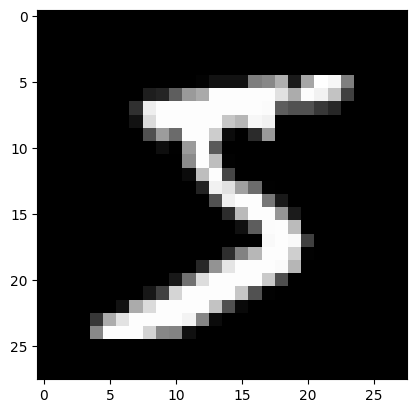

In [ ]:
#Visualize

plt.imshow(x_train[0], cmap= 'gray')
plt.show()

In [ ]:
#Adding Noise to our image
x_train_noisy = x_train_reshape + np.random.normal(loc=0.0,scale=1.0,size=(60000,28,28,1))

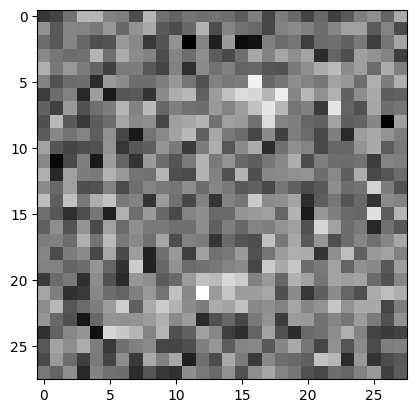

In [ ]:
plt.imshow(x_train_noisy[0], cmap= 'gray')
plt.show()

In [ ]:
#giving less noise
x_train_noisy = x_train_reshape + 0.2 * np.random.normal(loc=0.0,scale=1.0,size=(60000,28,28,1))  #Multiply with 0.2 to reduce the noise
x_test_noisy = x_test_reshape + 0.2 * np.random.normal(loc=0.0,scale=1.0,size=(10000,28,28,1))

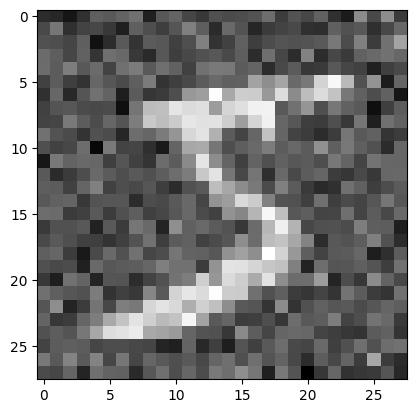

In [ ]:
plt.imshow(x_train_noisy[0], cmap= 'gray')
plt.show()

In [ ]:
#clipping the surrounding pixels to see even more clear
x_train_clipped = np.clip(a=x_train_noisy, a_min = 0, a_max = 2)
x_test_clipped = np.clip(a=x_test_noisy, a_min = 0, a_max = 2)

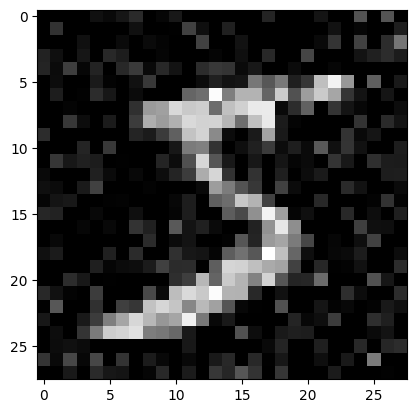

In [ ]:
plt.imshow(x_train_clipped[0], cmap= 'gray')
plt.show()

In [ ]:
#Encoder Architecture

model = Sequential()

model.add(Conv2D(input_shape=(28,28,1),filters =32,kernel_size=(3,3),strides = 1,padding='same',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides = 2))

model.add(Conv2D(filters =8,kernel_size=(3,3),strides = 1,padding='same',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides = 2))

model.add(Conv2D(filters =8,kernel_size=(3,3),strides = 1,padding='same',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides = 2,padding='same'))

model.summary()

# Output we qare getting is the "Bottle Neck"

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 8)      │         2,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 8)        │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,216 (12.56 KB)

 Trainable params: 3,216 (12.56 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Decoder Architecture

model.add(Conv2D(filters= 8,kernel_size=(3,3),strides = 1,padding='same',activation='relu'))
model.add(UpSampling2D(size=(2,2)))                                         #Instead of 'Maxpooling2D',here we use 'UpSampling2D'

model.add(Conv2D(filters= 8,kernel_size=(3,3),strides = 1,padding='same',activation='relu'))
model.add(UpSampling2D(size=(2,2)))

model.add(Conv2D(filters= 32,kernel_size=(3,3),strides = 1,activation='relu'))
model.add(UpSampling2D(size=(2,2)))

#Final Layer
model.add(Conv2D(filters= 1,kernel_size=(3,3),strides = 1,padding='same',activation='relu'))

model.summary()

#input and output will be same

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 8)      │         2,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 32)     │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,009 (27.38 KB)

 Trainable params: 7,009 (27.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer= "rmsprop", loss="mean_absolute_error")

In [ ]:
model.fit(x=x_train_clipped,y=x_train,epochs=10,batch_size=32)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.1307
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1307
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1307
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1307
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1307
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1307
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1307
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1307
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1307
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1307


In [ ]:
model.evaluate(x_test_noisy,x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1325


0.13251462578773499

In [ ]:
y_pred = model.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


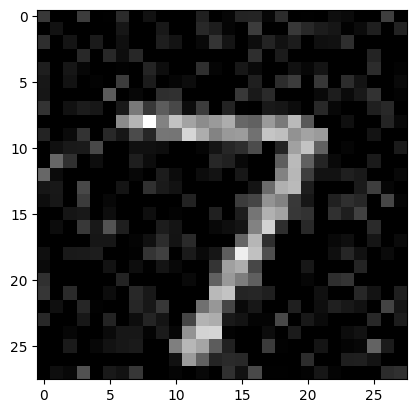

In [ ]:
plt.imshow(x_test_clipped[0], cmap= 'gray')
plt.show()

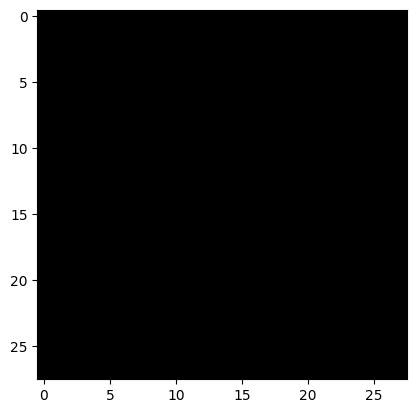

In [ ]:
plt.imshow(y_pred[0], cmap= 'gray')
plt.show()

In [ ]:
model.save("Denoising.h5")